In [48]:
#Dependencies for data
import nba_on_court as noc
import pandas as pd
import numpy as np
import os

if not hasattr(np, "in1d"):
    np.in1d = np.isin

In [49]:
import nba_api.stats.static.teams as find_team

#Function to download and combine on court data with shot details
def load_prep_data(player, year):
    #Download play by play
    noc.load_nba_data(seasons=year, data='nbastats', untar=True)
    play_by_play = pd.read_csv('nbastats_{}.csv'.format(year))
    #Remove data to avoid clogging up space
    os.remove('nbastats_{}.csv'.format(year))

    #Runs the player and year into a function to filter data to games that
    #the player plays in
    logs = player_filter(player,year).rename(columns= {'Game_ID':'GAME_ID'})
    logs['GAME_ID'] = logs['GAME_ID'].astype('int')

    #Get the list games played as well as what team they played for
    game_ids = logs['GAME_ID'].unique().tolist()
    team_abr = logs['MATCHUP'].str[:3].tolist()
    #Play filter
    plays = play_by_play.loc[play_by_play['GAME_ID'].isin(game_ids) == True]

    #Empty dataframe for iteration
    on_court_plays = pd.DataFrame()

    #Loop to bypass the function not working for every game
    #skips over games that return empty dataframes
    for game in game_ids:
        df = one_game_on_court(game,plays)
        if not df.empty:
            df['PLAYER1_TEAM_ID'] = df['PLAYER1_TEAM_ID'].fillna(0)
            df['PLAYER1_TEAM_ID'] = df['PLAYER1_TEAM_ID'].astype(int)
            i = game_ids.index(game)
            team = team_abr[i]
            id = find_team.find_team_by_abbreviation(team)['id']
            df = df.loc[df['PLAYER1_TEAM_ID'] == id]
            #Adds on to dataframe that will be used for analysis
            on_court_plays = pd.concat([on_court_plays, df], ignore_index=True)
        else:
            print(f"Warning: No data for GAME_ID {game}")

    #Name change for future merge
    on_court_plays = on_court_plays.rename(columns={'EVENTNUM':'GAME_EVENT_ID'})

    on_court_plays = on_court_plays[['GAME_ID', 'GAME_EVENT_ID','PLAYER1_ID',
                                  'PLAYER1_NAME', 'PLAYER1_TEAM_ID','PLAYER2_ID', 'PLAYER2_NAME',
                                   'PLAYER2_TEAM_ID','PLAYER3_ID', 'PLAYER3_NAME', 'PLAYER3_TEAM_ID',
                                   'AWAY_PLAYER1', 'AWAY_PLAYER2', 'AWAY_PLAYER3', 'AWAY_PLAYER4',
                                     'AWAY_PLAYER5', 'HOME_PLAYER1', 'HOME_PLAYER2', 'HOME_PLAYER3',
                                       'HOME_PLAYER4', 'HOME_PLAYER5']]
    
    #Bringing in location data
    noc.load_nba_data(seasons=year, data='shotdetail', untar=True)
    shots = pd.read_csv('shotdetail_{}.csv'.format(year))
    os.remove('shotdetail_{}.csv'.format(year))

    shots = shots[['GAME_ID', 'GAME_EVENT_ID','PERIOD', 'MINUTES_REMAINING',
                                  'SECONDS_REMAINING', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y'
                                 , 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG']]
    
    finished = on_court_plays.merge(shots, on=['GAME_ID','GAME_EVENT_ID'],
                                           how= 'inner')
    
    return finished

In [50]:
#Using the noc players on court function on individual games
#to avoid individual games from stopping whole function
def one_game_on_court(game_id,data_frame):
    game_ = data_frame.loc[data_frame['GAME_ID'] == game_id].reset_index().drop(columns='index')
    if game_.empty:
        print(f"Warning: No rows found for GAME_ID {game_id}")
        return pd.DataFrame()
    try:
        df = noc.players_on_court(game_)
#Skips games that timeout
    except Exception as e:
        print(f"ReadTimeout or other error for GAME_ID {game_id}: {e}")
        return pd.DataFrame()
    if df.empty:
        print(f"Warning: noc.players_on_court returned empty for GAME_ID {game_id}")
    return df

In [51]:
#Dependencies to get player game logs
import nba_api.stats.static.players as players
import nba_api.stats.endpoints.playergamelog as game_logs

#Custom header for api call
headers = {
    "Host": "stats.nba.com",
    "Connection": "keep-alive",
    "Accept": "application/json, text/plain, /",
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)",
    "Referer": "https://www.nba.com/",
    "Origin": "https://www.nba.com",
    "x-nba-stats-origin": "stats",
    "x-nba-stats-token": "true",
    "Accept-Language": "en-US,en;q=0.9"
    }
player_dicts = players.get_players()
working_player_dict = {player['id']: player['full_name'] for player in player_dicts}

def player_filter(player,year):
    
    log = game_logs.PlayerGameLog('{}'.format(player), headers= headers,
                                    season= '{}'.format(year)).get_data_frames()[0]
    
    return log


In [52]:
#On court filter
def on_court_plays(player,season):
    plays = load_prep_data(player,season)
    
    on_court_mask = (
    (plays['AWAY_PLAYER1'] == player) |
    (plays['AWAY_PLAYER2'] == player) |
    (plays['AWAY_PLAYER3'] == player) |
    (plays['AWAY_PLAYER4'] == player) |
    (plays['AWAY_PLAYER5'] == player) |
    (plays['HOME_PLAYER1'] == player) |
    (plays['HOME_PLAYER2'] == player) |
    (plays['HOME_PLAYER3'] == player) |
    (plays['HOME_PLAYER4'] == player) |
    (plays['HOME_PLAYER5'] == player)
)

    plays_with_player_on_court = plays[on_court_mask].copy().reset_index().drop(columns=
                                                                                       'index')
    return plays_with_player_on_court

In [53]:
#Off court filter
def off_court_plays(player,season):
    plays = load_prep_data(player,season)
    
    on_court_mask = (
    (plays['AWAY_PLAYER1'] != player) &
    (plays['AWAY_PLAYER2'] != player) &
    (plays['AWAY_PLAYER3'] != player) &
    (plays['AWAY_PLAYER4'] != player) &
    (plays['AWAY_PLAYER5'] != player) &
    (plays['HOME_PLAYER1'] != player) &
    (plays['HOME_PLAYER2'] != player) &
    (plays['HOME_PLAYER3'] != player) &
    (plays['HOME_PLAYER4'] != player) &
    (plays['HOME_PLAYER5'] != player)
)

    plays_with_player_off_court = plays[on_court_mask].copy().reset_index().drop(columns=
                                                                                       'index')
    return plays_with_player_off_court

In [54]:
#NBA Court graph item borrowed from https://github.com/bradleyfay/py-Goldsberry/blob/main/docs/Visualizing%20NBA%20Shots%20with%20py-Goldsberry.ipynb
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc
import matplotlib as mpl

def draw_court( ax=None, color='black',  lw=2, outer_lines=False):
    # If an axes object isn't provided to plot onto, just get current one
    if ax is None:
        ax = plt.gca()

    # Set background color to tan for the axes and figure
    ax.set_facecolor('#D2B48C')
    if ax.figure is not None:
        ax.figure.set_facecolor('#D2B48C')

    # Create the various parts of an NBA basketball court

    # Create the basketball hoop
    # Diameter of a hoop is 18" so it has a radius of 9", which is a value
    # 7.5 in our coordinate system
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Create backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # The paint
    # Create the outer box 0f the paint, width=16ft, height=19ft
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color,
                          fill=False)
    # Create the inner box of the paint, widt=12ft, height=19ft
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color,
                          fill=False)

    # Create free throw top arc
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180,
                         linewidth=lw, color=color, fill=False)
    # Create free throw bottom arc
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0,
                            linewidth=lw, color=color, linestyle='dashed')
    # Restricted Zone, it is an arc with 4ft radius from center of the hoop
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw,
                     color=color)

    # Three point line
    # Create the side 3pt lines, they are 14ft long before they begin to arc
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw,
                               color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    # 3pt arc - center of arc will be the hoop, arc is 23'9" away from hoop
    # I just played around with the theta values until they lined up with the 
    # threes
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw,
                    color=color)

    # Center Court
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0,
                           linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0,
                           linewidth=lw, color=color)

    # List of the court elements to be plotted onto the axes
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                      bottom_free_throw, restricted, corner_three_a,
                      corner_three_b, three_arc, center_outer_arc,
                      center_inner_arc]

    if outer_lines:
        # Draw the half court line, baseline and side out bound lines
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,
                                color=color, fill=False)
        court_elements.append(outer_lines)

    # Add the court elements onto the axes
    for element in court_elements:
        ax.add_patch(element)

    

    return ax

In [ ]:
#Dependencies for visualizations
from PIL import Image
import requests
from io import BytesIO

#Function for scatter plot of team shot locations with a player on the court
def plot_shots_on_court(player,season):
    plot = on_court_plays(player,season)
    fig = plt.figure(figsize=(15,11))
    plt.scatter(plot.loc[plot['SHOT_MADE_FLAG'] == 1, 'LOC_X'], 
                plot.loc[plot['SHOT_MADE_FLAG'] == 1, 'LOC_Y'], 
                color = 'red', label='Made')
    plt.scatter(plot.loc[plot['SHOT_MADE_FLAG'] == 0, 'LOC_X'], 
                plot.loc[plot['SHOT_MADE_FLAG'] == 0, 'LOC_Y'], 
                color = 'blue', label='Miss')
    draw_court(outer_lines=True, color="black")
    plt.xlim(-250,250)
    plt.ylim(-50,350)
    plt.axis('off')
    plt.legend(loc='upper left', fontsize=17)

    #Formatting of title
    if season <= 1999:
      plt.title('{}-{} Team Shot Chart with {} on Court'.format(season,
                                                                (f'{(season - 1899):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)
    else:
       plt.title('{}-{} Team Shot Chart with {} on Court'.format(season,
                                                                (f'{(season - 1999):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)

    #Downloads latest portrait of player
    url = 'https://cdn.nba.com/headshots/nba/latest/1040x760/{}.png'.format(player)
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    
    # Places portrait in the top right corner
    newax = fig.add_axes([0.77, 0.77, 0.125, 0.125], anchor='NE', zorder=1)
    newax.imshow(img)
    newax.axis('off')
    
    plt.show()

In [ ]:
#Copy of previous function but with player off the court
def plot_shots_off_court(player,season):
    plot =off_court_plays(player,season)
    fig = plt.figure(figsize=(15,11))
    plt.scatter(plot.loc[plot['SHOT_MADE_FLAG'] == 1, 'LOC_X'], 
                plot.loc[plot['SHOT_MADE_FLAG'] == 1, 'LOC_Y'], 
                color = 'red', label='Made')
    plt.scatter(plot.loc[plot['SHOT_MADE_FLAG'] == 0, 'LOC_X'], 
                plot.loc[plot['SHOT_MADE_FLAG'] == 0, 'LOC_Y'], 
                color = 'blue', label='Miss')
    draw_court( outer_lines=True, color="black")
    plt.xlim(-250,250)
    plt.ylim(-50,350)
    plt.axis('off')
    plt.legend(loc='upper left', fontsize=17)
    if season <= 1999:
      plt.title('{}-{} Team Shot Chart with {} off Court'.format(season,
                                                                (f'{(season - 1899):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)
    else:
       plt.title('{}-{} Team Shot Chart with {} off Court'.format(season,
                                                                (f'{(season - 1999):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)
    
    url = 'https://cdn.nba.com/headshots/nba/latest/1040x760/{}.png'.format(player)
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    
    newax = fig.add_axes([0.77, 0.77, 0.125, 0.125], anchor='NE', zorder=1)
    newax.imshow(img)
    newax.axis('off')
    
    plt.show()

In [ ]:
#Function that bins together shot locations and turns it into a hex plot for clearer visualization
def hex_plot_on_court(player,season):
    plot =on_court_plays(player,season)
    norm = mpl.colors.Normalize()
    fig = plt.figure(figsize=(15,11))
    ax = fig.add_subplot(111)
    #Added a shot quantity filter to get rid of unnecessary clutter and placed a color gradient to
    # highlight where the hotzones(most shots taken) are 
    ax.hexbin(plot.LOC_X, plot.LOC_Y, gridsize=25, bins='log', cmap='inferno',
               mincnt= (plot.shape[0])*.0025)
    draw_court( outer_lines=True, color="black")
    plt.xlim(-250,250)
    plt.ylim(-50,350)
    plt.axis('off')

    #Same formatting method as earlier
    if season <= 1999:
      plt.title('{}-{} Team Shot Chart with {} on Court'.format(season,
                                                                (f'{(season - 1899):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)
    else:
       plt.title('{}-{} Team Shot Chart with {} on Court'.format(season,
                                                                (f'{(season - 1999):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)
    
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='inferno'),  ax=ax,
                label='Frequency', orientation='horizontal')
    
    #Same as other portrait download and placement code
    url = 'https://cdn.nba.com/headshots/nba/latest/1040x760/{}.png'.format(player)
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    
    newax = fig.add_axes([0.77, 0.77, 0.125, 0.125], anchor='NE', zorder=1)
    newax.imshow(img)
    newax.axis('off')

    plt.show()


In [ ]:
#Copy of previous function but with player off the court
def hex_plot_off_court(player,season):
    plot =off_court_plays(player,season)
    norm = mpl.colors.Normalize()
    fig = plt.figure(figsize=(15,11))
    ax = fig.add_subplot(111)
    ax.hexbin(plot.LOC_X, plot.LOC_Y, gridsize=25, bins='log', cmap='inferno',
               mincnt= (plot.shape[0])*.0025)
    draw_court( outer_lines=True, color="black")
    plt.xlim(-250,250)
    plt.ylim(-50,350)
    plt.axis('off')
    if season <= 1999:
      plt.title('{}-{} Team Shot Chart with {} off Court'.format(season,
                                                                (f'{(season - 1899):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)
    else:
       plt.title('{}-{} Team Shot Chart with {} off Court'.format(season,
                                                                (f'{(season - 1999):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)
    
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='inferno'),  ax=ax,
                label='Frequency', orientation='horizontal')
    
    url = 'https://cdn.nba.com/headshots/nba/latest/1040x760/{}.png'.format(player)
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    
    newax = fig.add_axes([0.77, 0.77, 0.125, 0.125], anchor='NE', zorder=1)
    newax.imshow(img)
    newax.axis('off')

    plt.show()



In [ ]:
#More dependencies
import random
from nba_api.stats.endpoints import leagueleaders
#Function that selects a random player, fun side feature
def random_player():
    #List of elligible years
    year_range = list(range(1996,2026))
    #Random year selection
    year = random.choice(year_range)

    #Formats year for function use
    #Function calls api to get a league leaders dataframe
    if year <= 1999:
      leaderboard = leagueleaders.LeagueLeaders(season='{}-{}'.format(year,
                                                                (f'{(year - 1899):02d}')))
    else:
       leaderboard = leagueleaders.LeagueLeaders(season='{}-{}'.format(year,
                                                                (f'{(year - 1999):02d}')))

    
    df = leaderboard.league_leaders.get_data_frame()

    #Creates list of players from leaderboard to have a list of elligible players
    players = df['PLAYER_ID'].unique().tolist()

    #Takes random player from list
    player = random.choice(players)

    #To use random player function in other functions, input as *random_player()
    return player, year

In [ ]:
#Function takes shots made while player is on the court and groups them based on how involved
#the player was
def plot_player_involvement(player,season):
    plot =on_court_plays(player,season)
    plot = plot.loc[plot['SHOT_MADE_FLAG'] == 1]
    fig = plt.figure(figsize=(15,11))
    #Overlaying scatter plots that define the involvement levels
    plt.scatter(plot.loc[plot['PLAYER1_ID'] == player, 'LOC_X'], 
                plot.loc[plot['PLAYER1_ID'] == player, 'LOC_Y'], 
                color = 'red', label='Made by {}'.format(working_player_dict[player]))
    plt.scatter(plot.loc[plot['PLAYER2_ID'] == player, 'LOC_X'], 
                plot.loc[plot['PLAYER2_ID'] == player, 'LOC_Y'], 
                color = 'blue', label='Assisted by {}'.format(working_player_dict[player]))
    plt.scatter(plot.loc[((plot['PLAYER1_ID'] != player) & (plot['PLAYER2_ID'] != player)), 'LOC_X'],
                plot.loc[((plot['PLAYER1_ID'] != player) & (plot['PLAYER2_ID'] != player)), 'LOC_Y'],
                color = 'green', label='Not Involving {}'.format(working_player_dict[player]))
    draw_court(outer_lines=True, color="black")
    plt.xlim(-250,250)
    plt.ylim(-50,350)
    plt.axis('off')
    plt.legend(loc='upper left', fontsize=17)
    if season <= 1999:
      plt.title('{}-{} Team Shot Chart with {} on Court'.format(season,
                                                                (f'{(season - 1899):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)
    else:
       plt.title('{}-{} Team Shot Chart with {} on Court'.format(season,
                                                                (f'{(season - 1999):02d}'),
                                                                working_player_dict[player]),
                                                                  size=16)
    
    url = 'https://cdn.nba.com/headshots/nba/latest/1040x760/{}.png'.format(player)
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    
    newax = fig.add_axes([0.77, 0.77, 0.125, 0.125], anchor='NE', zorder=1)
    newax.imshow(img)
    newax.axis('off')
    
    plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

#Function to calculate the similarity between a team's shot selection with a player on vs off
#the court using cosine similarity
def similarity_check(player, year):
    #Get shot locations
    matrix_on = on_court_plays(player, year)[['LOC_X', 'LOC_Y']].to_numpy()
    matrix_off = off_court_plays(player, year)[['LOC_X', 'LOC_Y']].to_numpy()

    #Define court bins
    x_bins = np.linspace(-250, 250, 25)
    y_bins = np.linspace(-50, 470, 25)

    #Create 2D histograms
    hist_on, _, _ = np.histogram2d(matrix_on[:,0], matrix_on[:,1], bins=[x_bins, y_bins])
    hist_off, _, _ = np.histogram2d(matrix_off[:,0], matrix_off[:,1], bins=[x_bins, y_bins])

    #Flatten histograms
    vector_on = hist_on.flatten().reshape(1, -1)
    vector_off = hist_off.flatten().reshape(1, -1)

    #Compute similarity
    score = cosine_similarity(vector_on, vector_off)[0][0]

    return "{}'s shot profile similarity is {}".format(working_player_dict[player], score)

In [63]:
similarity_check(201939,2022)

ReadTimeout or other error for GAME_ID 22200410: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=10)
ReadTimeout or other error for GAME_ID 22200082: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=10)
ReadTimeout or other error for GAME_ID 22200410: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=10)
ReadTimeout or other error for GAME_ID 22200082: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=10)


"Stephen Curry's shot profile similarity is 0.9538147659281444"

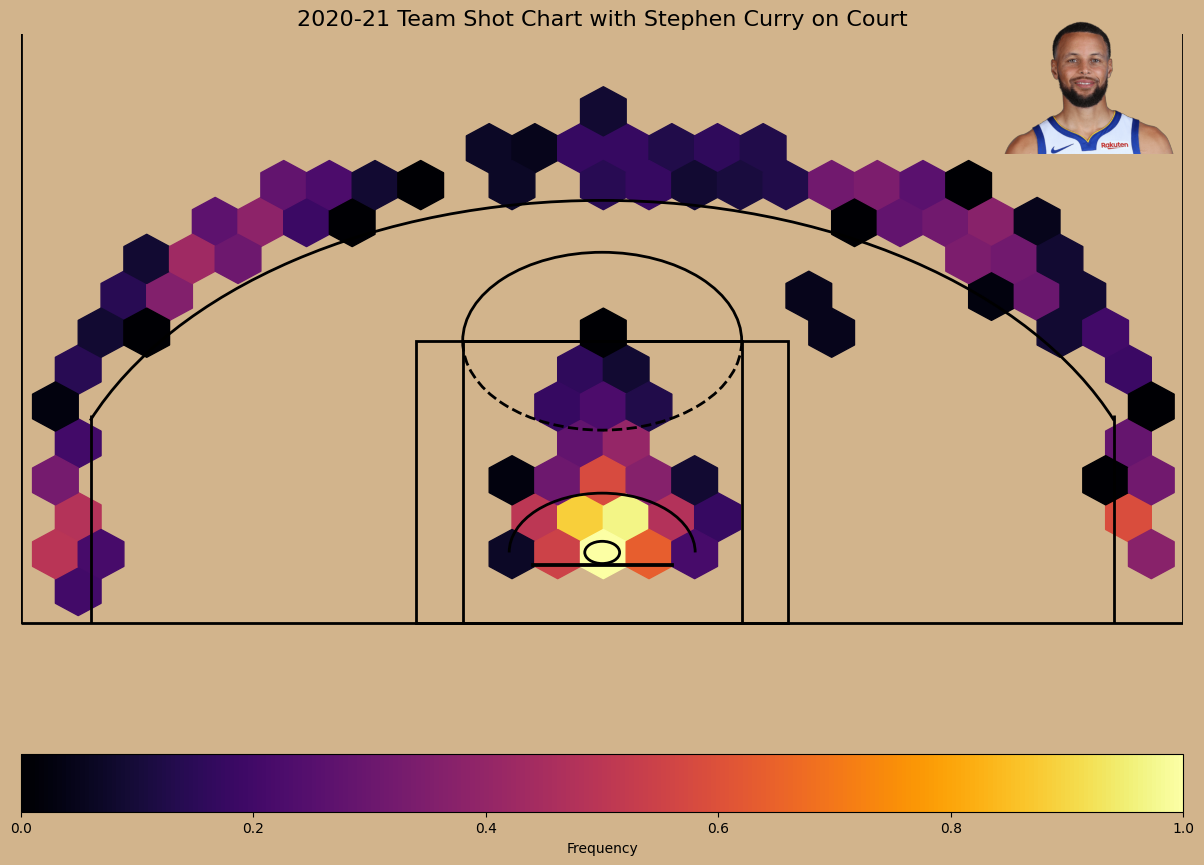

In [69]:
hex_plot_on_court(201939,2020)

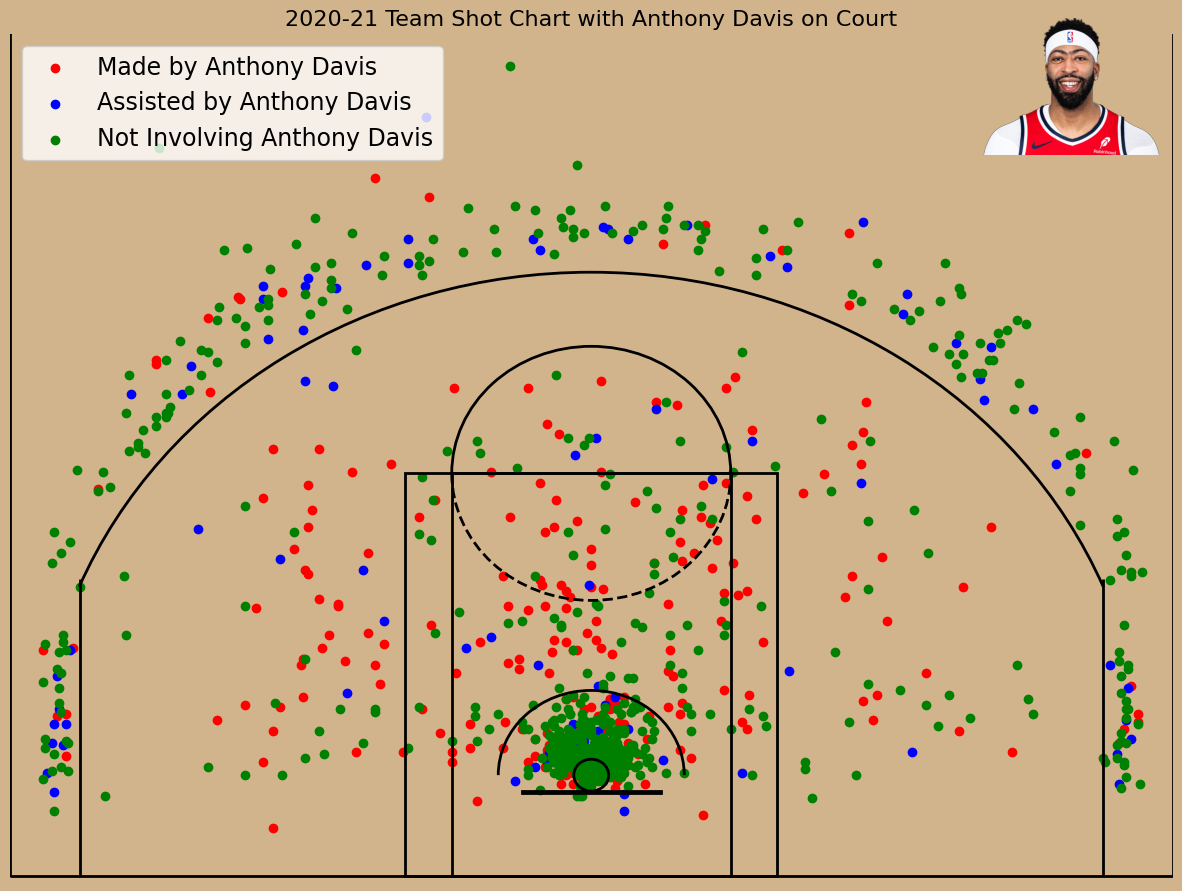

In [65]:
plot_player_involvement(203076,2020)